In [3]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt


def result_files(rundir):
    evaldir = 'eval-results'
    return sorted(glob.glob(os.path.join(rundir, evaldir) + '/*'))


def get_testset_names(result_files):
    testset_names = set()
    for results_file in result_files:
        testset_name = results_file.split('/')[-1].replace('eval-', '')[5:].replace('.out', '')
        testset_names.add(testset_name)
    return testset_names


def get_batch_ind(results_file):
    return int(results_file.split('/')[-1].replace('eval-', '')[:4])

def number_of_docs(batchdir):
    return len(glob.glob(os.path.join(batchdir, '*.txt')))


def get_results(rundir, skiprows=0):
    resfiles = result_files(rundir)
    testset_names = get_testset_names(resfiles)
    df = pd.DataFrame()
    for resfile in sorted(resfiles):
        batch_ind = get_batch_ind(resfile)
        testset = get_testset_names([resfile])
        try:
            dft = pd.read_csv(resfile, sep='\t', skiprows=skiprows, header=None, index_col=0).T             
        except pd.errors.EmptyDataError:
            pass
        dft['testset'] = testset
        dft['batch'] = batch_ind
        trainsetdir = os.path.join(rundir, f'train-batch-{batch_ind:04}')
        dft['Documents_in_learn_batch'] = number_of_docs(trainsetdir)
        df = df.append(dft)
    df.rename(columns=lambda x: x.replace(':', '').strip(), inplace=True)
    df['Documents_learned'] = df.groupby('testset')['Documents_in_learn_batch'].transform(pd.Series.cumsum)
    return df


def plot_results(df, metric='F1@5', figsize=(8, 8), **kwargs):
    for testset, df_testset in df.groupby('testset'):
        df_testset.set_index('Documents_learned')[metric].plot(
            ax=plt.gca(), label=testset, figsize=figsize, **kwargs)
    
    plt.xlabel('Number of learned documents')
    plt.ylabel(metric)
    #fig = plt.gcf()
    #fig.set_size_inches(8, 8)
    plt.grid()
    return plt.gcf(), plt.gca()


In [26]:
df_init = get_results('run-initial-train', skiprows=18)  # 18 first rows in results file contain uninteded logs

df_run0 = get_results('run-0', skiprows=18)  # 18 first rows in results file contain uninteded logs
df_run1 = get_results('run-1')
df_run3 = get_results('run-3', skiprows=18)  # 18 first rows in results file contain uninteded logs
df_run4 = get_results('run-4')
df_run5 = get_results('run-5', skiprows=18)


In [29]:
df_init_table = pd.DataFrame({
    'testset': 
    	[
    	'fulltext-jyu-theses-fin-test', 
    	'fulltext-kirjastonhoitaja-test',
    	'satakunnan-kansa',
    	'vapaakappaleet-fi-2019', 
    	'kirjaesittelyt-yso-fin-test', 
    	],
	'F1@5': [
		0.4288,
		0.3573,
		0.3202,
		0.4121,
		0.4602,
	]
})
df_init_table['Documents_learned'] = 0

Text(0.5, 1.0, 'Learning and training on batches of JYU thesis\n solid line = learn epochs 1  \n -*- = learn epochs 4 \n ··+·· = train-from-scratch')

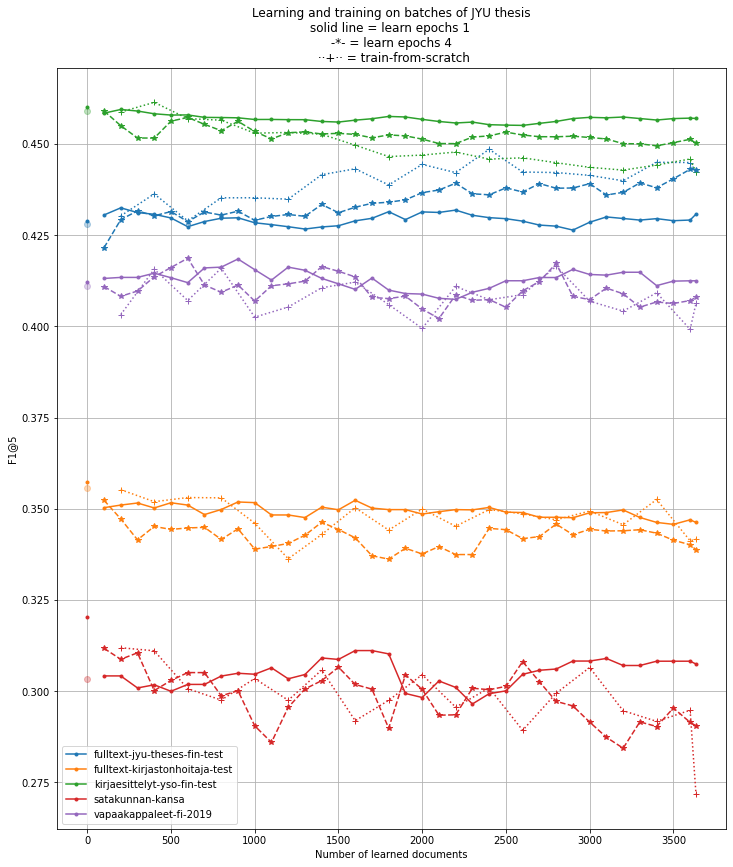

In [31]:
# plot_results(df_run0, marker='o', linestyle='--')
#plt.legend()

plt.gca().set_prop_cycle(None)
plot_results(df_run1, marker='.')
plt.legend()

plt.gca().set_prop_cycle(None)
plot_results(df_init_table, marker='.')
plt.gca().set_prop_cycle(None)
plot_results(df_init, marker='o', alpha=0.3)

plt.gca().set_prop_cycle(None)
plot_results(df_run5, marker='+', linestyle=':')

plt.gca().set_prop_cycle(None)
plot_results(df_run4, marker='*', linestyle='--', figsize=(12, 14))

plt.title('Learning and training on batches of JYU thesis\n \
solid line = learn epochs 1  \n -*- = learn epochs 4 \n ··+·· = train-from-scratch')

Text(0.5, 1.0, 'Learning on vapaakappaleet (from year 2018) \nwith epochs = 1 (solid line) and epochs = 4 (--*--)')

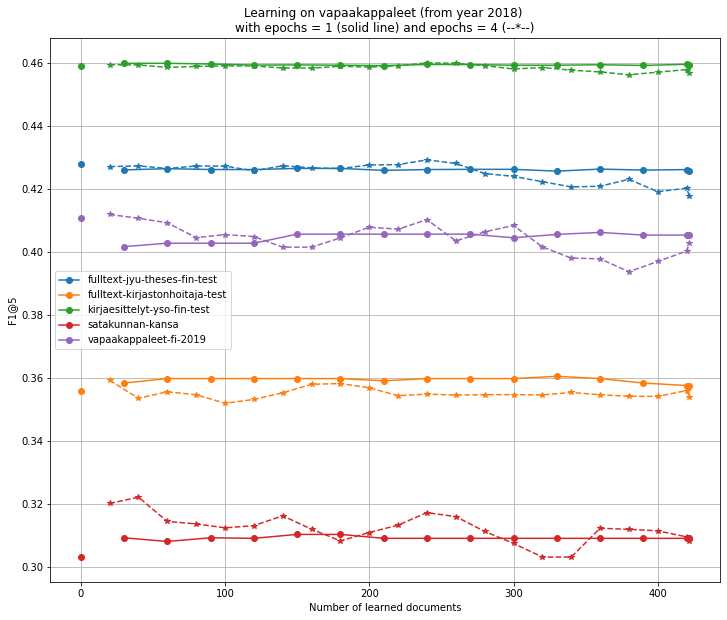

In [34]:
df_run2 = get_results('run-2')
df_run7 = get_results('run-7')

plot_results(df_run2, marker='o', linestyle='-', figsize=(12, 10))
plt.legend()
plt.gca().set_prop_cycle(None)
plot_results(df_init, marker='o')

plt.gca().set_prop_cycle(None)
plot_results(df_run7, marker='*', linestyle='--', figsize=(12, 10))

plt.title('Learning on vapaakappaleet (from year 2018) \nwith epochs = 1 (solid line) and epochs = 4 (--*--)')

Text(0.5, 1.0, 'Learning on kirjaesittelyt with epochs = 4')

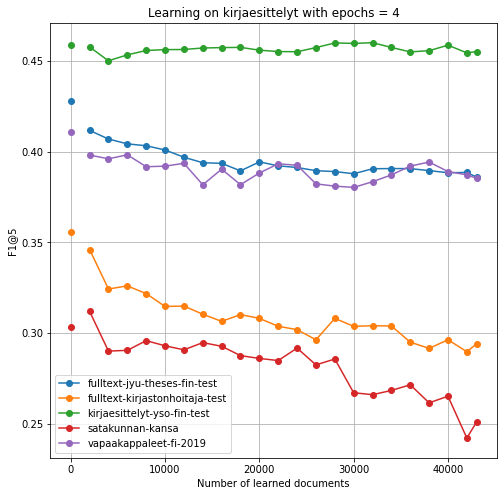

In [33]:
df_run6 = get_results('run-6')

plot_results(df_run6, marker='o', linestyle='-', figsize=(12, 10))
plt.legend()
plt.gca().set_prop_cycle(None)
plot_results(df_init, marker='o')

plt.title('Learning on kirjaesittelyt with epochs = 4')